In [1]:
# Install Java 11
!apt-get update -y
!apt-get install openjdk-11-jdk -y

# Install PySpark
!pip install pyspark


Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 https://cli.github.com/packages stable InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,125 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,526 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,437 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:13 https://ppa.launchpadcontent.net/graphics-drivers/p

In [2]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = "/usr/local/lib/python3.12/dist-packages/pyspark"


In [3]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("PneumoNet_Preprocessing").getOrCreate()


In [4]:
# ============================================================
# PNEUMONET - CNN for Pneumonia Detection using Chest X-Ray
# Dataset: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
# ============================================================

!pip install pyspark gradio seaborn --quiet

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import gradio as gr
from pyspark.sql import SparkSession
from google.colab import drive


In [5]:
# ============================================================
# 🔗 0️⃣ MOUNT GOOGLE DRIVE
# ============================================================

drive.mount('/content/drive')

Set dataset path in Drive (update if needed)
#dataset_path = "/content/drive/MyDrive/chest_xray"


Mounted at /content/drive


In [6]:
# ============================================================
# 1️⃣ Spark Session and Dataset Preprocessing
# ============================================================

spark = SparkSession.builder.appName("PneumoNet_Preprocessing").getOrCreate()

train_dir = os.path.join(dataset_path, "train")
val_dir = os.path.join(dataset_path, "val")
test_dir = os.path.join(dataset_path, "test")

# Define transformations (resize, normalization, augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229])
])

# Spark inspection
train_df = spark.read.format("binaryFile").load(f"{train_dir}/*/*")
val_df = spark.read.format("binaryFile").load(f"{val_dir}/*/*")
test_df = spark.read.format("binaryFile").load(f"{test_dir}/*/*")

print("Dataset sizes (Spark inspection):")
print("Train:", train_df.count(), " Validation:", val_df.count(), " Test:", test_df.count())

# PyTorch dataset loaders
train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
val_data = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_data = datasets.ImageFolder(test_dir, transform=val_test_transforms)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)


Dataset sizes (Spark inspection):
Train: 5216  Validation: 16  Test: 624


In [7]:
# ============================================================
# 2️⃣ CNN MODEL DEFINITION
# ============================================================

class PneumoNetCNN(nn.Module):
    def __init__(self):
        super(PneumoNetCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PneumoNetCNN().to(device)
print(model)


PneumoNetCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=256, out_features=2, bias=True)
  )
)


In [8]:
spark.stop()
print("Spark session stopped to free memory.")

Spark session stopped to free memory.


In [9]:
# ============================================================
# 3️⃣ TRAINING THE MODEL (with Accuracy)
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 10

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    # ----- Training -----
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct_train / total_train
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    # ----- Validation -----
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct_val / total_val
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")


Epoch [1/10] Train Loss: 0.3139 | Val Loss: 0.9226 | Train Acc: 87.86% | Val Acc: 62.50%
Epoch [2/10] Train Loss: 0.1499 | Val Loss: 0.8008 | Train Acc: 94.15% | Val Acc: 68.75%
Epoch [3/10] Train Loss: 0.1105 | Val Loss: 0.8741 | Train Acc: 95.82% | Val Acc: 62.50%
Epoch [4/10] Train Loss: 0.1075 | Val Loss: 0.8740 | Train Acc: 96.15% | Val Acc: 62.50%
Epoch [5/10] Train Loss: 0.1034 | Val Loss: 0.8698 | Train Acc: 96.13% | Val Acc: 62.50%
Epoch [6/10] Train Loss: 0.0887 | Val Loss: 0.8422 | Train Acc: 96.70% | Val Acc: 68.75%
Epoch [7/10] Train Loss: 0.0925 | Val Loss: 1.3087 | Train Acc: 96.64% | Val Acc: 56.25%
Epoch [8/10] Train Loss: 0.0887 | Val Loss: 0.9743 | Train Acc: 96.53% | Val Acc: 62.50%
Epoch [9/10] Train Loss: 0.0817 | Val Loss: 1.1195 | Train Acc: 97.12% | Val Acc: 62.50%
Epoch [10/10] Train Loss: 0.0887 | Val Loss: 0.5981 | Train Acc: 96.74% | Val Acc: 68.75%


In [36]:
# ============================================================
# CELL 5 - SAVE & LOAD MODEL FROM DRIVE
# ============================================================

# Define the path to save/load the model in Google Drive
model_drive_path = "/content/drive/MyDrive/pneumonet_cnn.pth"

# ----- Save the trained model -----
torch.save(model.state_dict(), model_drive_path)
print(f"Model saved successfully to Drive at {model_drive_path}")

# ----- Load the model back from Drive -----
loaded_model = PneumoNetCNN().to(device)
loaded_model.load_state_dict(torch.load(model_drive_path))
loaded_model.eval()
print("Model loaded successfully from Drive and ready for evaluation/Gradio")


Model saved successfully to Drive at /content/drive/MyDrive/pneumonet_cnn.pth
Model loaded successfully from Drive and ready for evaluation/Gradio


Accuracy: 0.7612
Precision: 0.7304
Recall: 0.9795
F1 Score: 0.8368
ROC-AUC: 0.9044


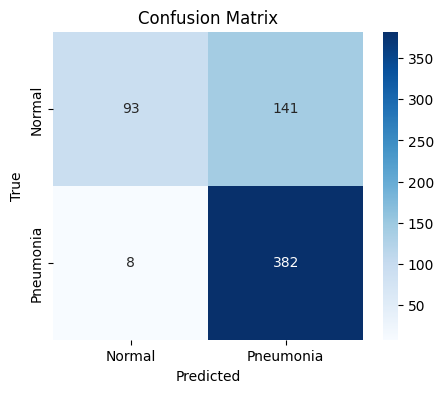

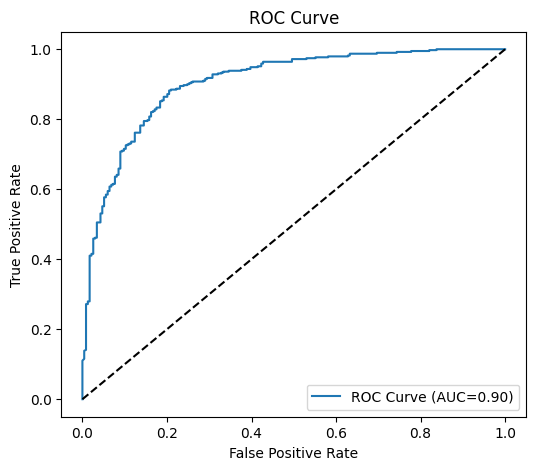

In [11]:
# ============================================================
# CELL 7 - EVALUATION ON TEST SET WITH METRICS, ROC, CONFUSION
# ============================================================

y_true, y_pred, y_probs = [], [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = loaded_model(inputs)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_probs)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_probs)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC={roc_auc:.2f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


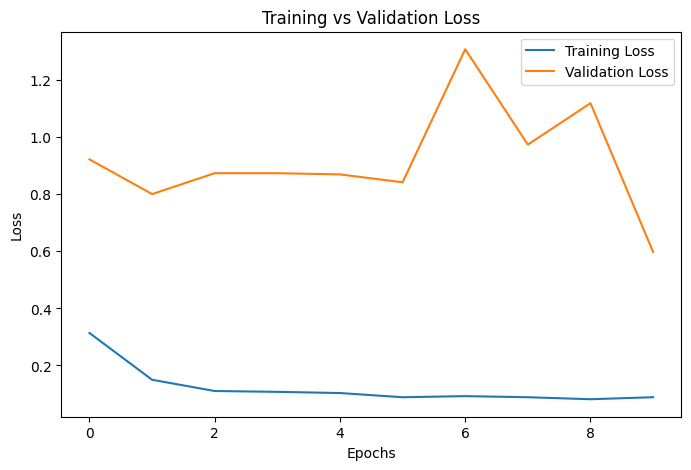

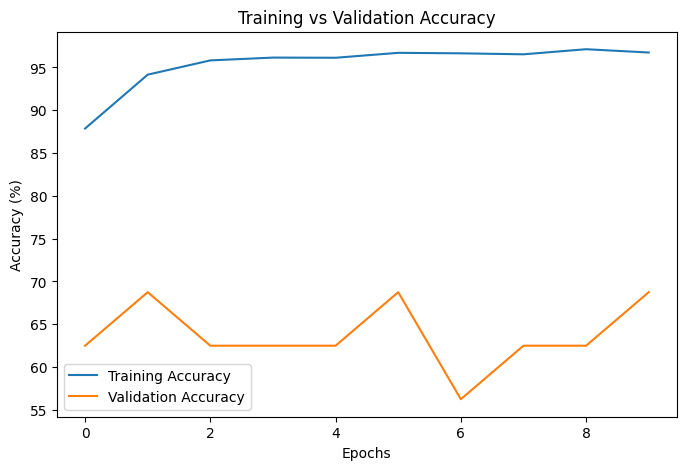

Target layer for Grad-CAM: Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


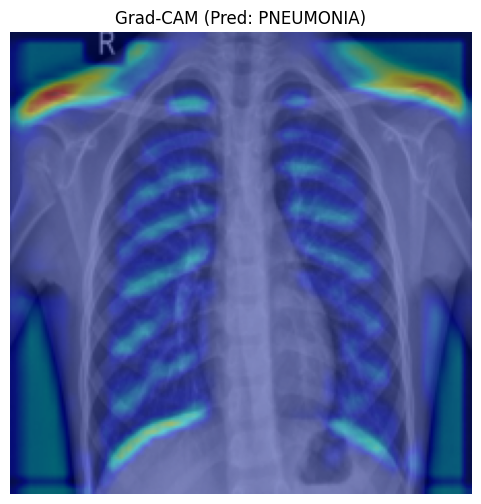

In [37]:
# ============================================================
# CELL 8 - PLOT TRAINING/VALIDATION LOSS
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

# ============================================================
# 🔟 Grad-CAM Visualization (Compatible with PneumoNetCNN)
# ============================================================

import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt

def find_last_conv_layer(model):
    """
    Automatically finds the last convolutional layer in the model.
    Works for custom CNN architectures.
    """
    last_conv = None
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Conv2d):
            last_conv = module
    return last_conv


def generate_gradcam(model, img_tensor, target_layer):
    """
    Generates Grad-CAM heatmap for any CNN model.
    """
    model.eval()
    gradients, activations = [], []

    # Hook functions
    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0].detach())

    def forward_hook(module, inp, out):
        activations.append(out.detach())

    # Register hooks
    h_f = target_layer.register_forward_hook(forward_hook)
    h_b = target_layer.register_backward_hook(backward_hook)

    # Forward pass
    outputs = model(img_tensor)
    pred_class = outputs.argmax(dim=1)

    # Backward pass
    model.zero_grad()
    outputs[0, pred_class].backward()

    # Convert to numpy
    grads = gradients[0].cpu().numpy()[0]
    acts = activations[0].cpu().numpy()[0]

    # Compute weights and Grad-CAM
    weights = np.mean(grads, axis=(1, 2))
    cam = np.zeros(acts.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * acts[i, :, :]

    cam = np.maximum(cam, 0)
    cam /= cam.max() if cam.max() != 0 else 1

    # Remove hooks
    h_f.remove()
    h_b.remove()

    return cam, pred_class.item()


# ============================================================
# 🩻 Generate Grad-CAM for a Sample Image
# ============================================================

# Get one test sample
sample_img, _ = test_data[0]
input_tensor = sample_img.unsqueeze(0).to(device)

# Automatically find last conv layer in PneumoNetCNN
target_layer = find_last_conv_layer(loaded_model)
print(f"Target layer for Grad-CAM: {target_layer}")

# Generate Grad-CAM heatmap
cam, pred = generate_gradcam(loaded_model, input_tensor, target_layer)

# ============================================================
# 🖼️ Visualization
# ============================================================

# Undo normalization for proper visualization
img_np = sample_img.cpu().numpy().transpose(1, 2, 0)
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
img_unnorm = np.clip(std * img_np + mean, 0, 1)
img_disp = np.uint8(img_unnorm * 255)

# Resize and overlay CAM
cam_resized = cv2.resize(cam, (224, 224))
heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
overlay = cv2.addWeighted(heatmap, 0.4, img_disp, 0.6, 0)

plt.figure(figsize=(6,6))
plt.imshow(overlay[..., ::-1])
plt.title(f"Grad-CAM (Pred: {'PNEUMONIA' if pred==1 else 'NORMAL'})")
plt.axis('off')
plt.show()






Background batch: torch.Size([8, 3, 224, 224]), Test samples: torch.Size([2, 3, 224, 224])
✅ Final SHAP shape: (2, 224, 224, 3), image shape: (2, 224, 224, 3)


<Figure size 600x600 with 0 Axes>

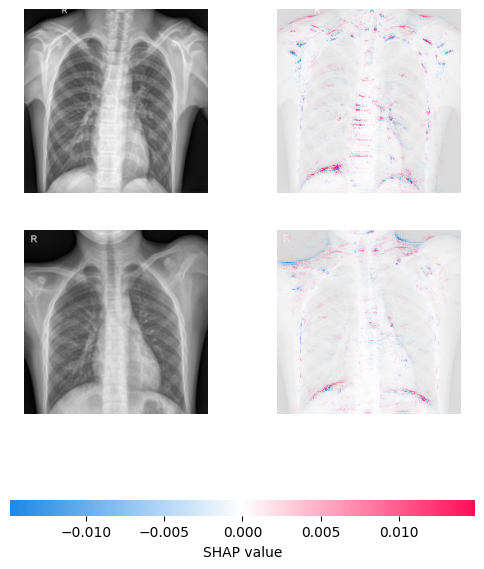

<Figure size 600x600 with 0 Axes>

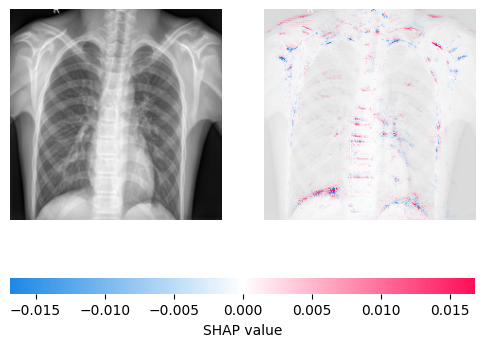

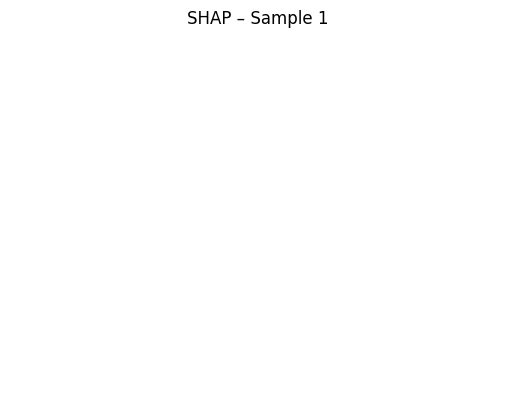

<Figure size 600x600 with 0 Axes>

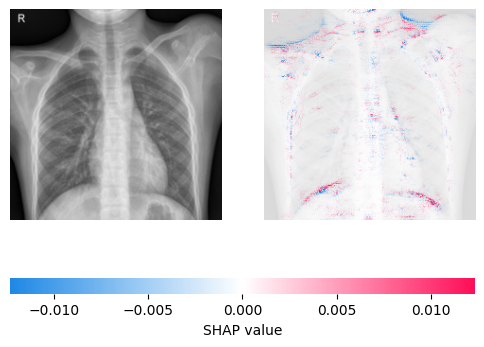

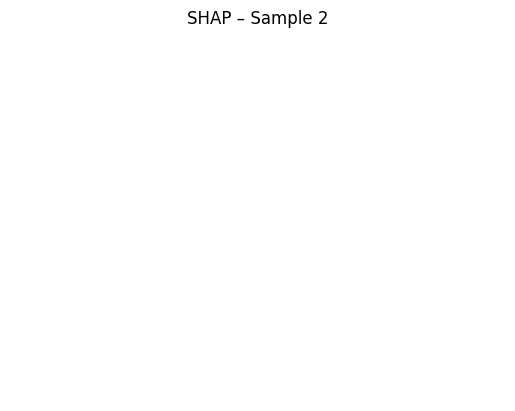

In [43]:
# ============================================================
# 🔍 SHAP GradientExplainer for PneumoNetCNN (Final Fixed Version)
# ============================================================

!pip install -q shap
import shap, torch, numpy as np, matplotlib.pyplot as plt
import copy

# ---- 1️⃣ Create clean isolated model ----
model_for_shap = copy.deepcopy(loaded_model).to(device)
model_for_shap.eval()
torch.cuda.empty_cache()

# ---- 2️⃣ Prepare background and test samples ----
bg, xs = [], []
for images, _ in test_loader:
    for img in images:
        if len(bg) < 8:
            bg.append(img)
        elif len(xs) < 2:
            xs.append(img)
        else:
            break
    if len(xs) >= 2:
        break

bg = torch.stack(bg).to(device)
X  = torch.stack(xs).to(device)

print(f"Background batch: {bg.shape}, Test samples: {X.shape}")

# ---- 3️⃣ Run GradientExplainer (no hooks) ----
explainer = shap.GradientExplainer(model_for_shap, bg)
sv_raw = explainer.shap_values(X)

# ---- 4️⃣ Normalize and handle class dimension ----
if isinstance(sv_raw, list):
    shap_values = sv_raw[0]
else:
    shap_values = sv_raw

if torch.is_tensor(shap_values):
    sv_np = shap_values.detach().cpu().numpy()
else:
    sv_np = np.array(shap_values)

# If SHAP gives multi-logit output (e.g. (N, C, H, W, 2)), select pneumonia class (index 1)
if sv_np.ndim == 5 and sv_np.shape[-1] == 2:
    sv_np = sv_np[..., 1]

# Now sv_np should be (N, C, H, W)
if sv_np.ndim == 4 and sv_np.shape[1] in [1, 3]:
    sv_np = np.transpose(sv_np, (0, 2, 3, 1))  # → (N, H, W, C)
elif sv_np.ndim == 4 and sv_np.shape[-1] not in [1, 3]:
    sv_np = sv_np[..., np.newaxis]

# replicate grayscale to RGB
if sv_np.shape[-1] == 1:
    sv_np = np.repeat(sv_np, 3, axis=-1)

# ---- 5️⃣ Normalize the test images ----
X_np = X.detach().cpu().permute(0, 2, 3, 1).numpy()
X_np = (X_np - X_np.min()) / (X_np.max() - X_np.min())
if X_np.shape[-1] == 1:
    X_np = np.repeat(X_np, 3, axis=-1)

print(f"✅ Final SHAP shape: {sv_np.shape}, image shape: {X_np.shape}")

# ---- 6️⃣ Plot SHAP heatmaps ----
plt.figure(figsize=(6, 6))
shap.image_plot(sv_np, X_np)
plt.show()

for i in range(X_np.shape[0]):
    plt.figure(figsize=(6, 6))
    shap.image_plot(sv_np[i:i+1], X_np[i:i+1])
    plt.title(f"SHAP – Sample {i+1}")
    plt.axis("off")
    plt.show()

# ---- 7️⃣ Cleanup ----
del sv_np, X_np, bg, X, model_for_shap, explainer
torch.cuda.empty_cache()


  0%|          | 0/1000 [00:00<?, ?it/s]

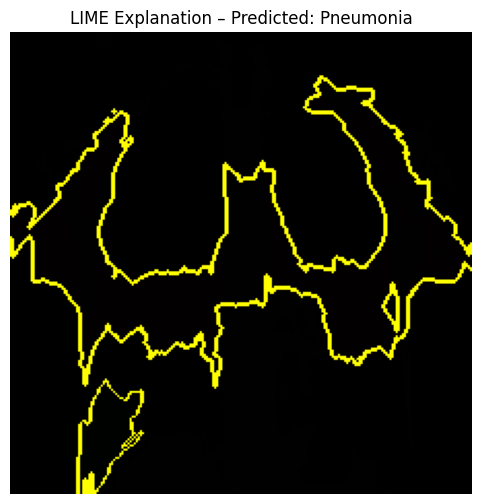

In [39]:
# ============================================================
#  LIME Explainability for Baseline CNN
# ============================================================

!pip install lime --quiet
from lime import lime_image
from skimage.segmentation import mark_boundaries
import numpy as np
import matplotlib.pyplot as plt

# Ensure model is in eval mode
loaded_model.eval()

# Helper: Predict function for LIME
def predict_fn(images):
    """Takes a list/array of images and returns model probabilities."""
    loaded_model.eval()
    batch = []
    for img in images:
        # Convert to tensor, normalize, and add batch dimension
        img_t = torch.tensor(img.transpose((2, 0, 1)), dtype=torch.float32)
        img_t = (img_t / 255.0 - 0.485) / 0.229
        batch.append(img_t)
    batch = torch.stack(batch).to(device)
    with torch.no_grad():
        outputs = loaded_model(batch)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
    return probs

# Create a LIME explainer
explainer = lime_image.LimeImageExplainer()

# Select a test image for explanation (from your test dataset)
test_iter = iter(test_loader)
images, labels = next(test_iter)
img = images[0].permute(1, 2, 0).cpu().numpy()
label = labels[0].item()

# Run LIME explanation
explanation = explainer.explain_instance(
    img.astype('double'),
    predict_fn,
    top_labels=2,
    hide_color=0,
    num_samples=1000
)

# Get the explanation for the predicted label
top_label = explanation.top_labels[0]
temp, mask = explanation.get_image_and_mask(
    top_label,
    positive_only=False,
    num_features=8,
    hide_rest=False
)

# Visualize the explanation
plt.figure(figsize=(6,6))
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title(f"LIME Explanation – Predicted: {'Pneumonia' if top_label == 1 else 'Normal'}")
plt.axis('off')
plt.show()


In [42]:
# ============================================================
# 9️⃣ GRADIO APP FOR IMAGE PREDICTION
# ============================================================

def predict_pneumonia(img):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485], std=[0.229])
    ])
    img = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = loaded_model(img)
        probs = torch.softmax(outputs, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        label = "PNEUMONIA" if pred == 1 else "NORMAL"
        confidence = probs[0][pred].item()
    return {label: confidence}

interface = gr.Interface(
    fn=predict_pneumonia,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=2),
    title="PneumoNet - Pneumonia Detection",
    description="Upload a chest X-ray image to predict whether it's Pneumonia or Normal."
)

interface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0e91b729546dacb3fd.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
